<a href="https://colab.research.google.com/github/aitoufkir-khadija2004/Exercise-Pose-Correction-_Module-AAI/blob/main/AAI_Exercise_Pose_Correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install -q mediapipe==0.10.13
!pip install -q opencv-python-headless kaggle
print(" Installation OK")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 20.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
 Installation OK


In [11]:

import os, cv2, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
warnings.filterwarnings('ignore')


In [12]:

# Dossiers de travail
BASE = '/content/fitness_data'
for folder in ['videos/raw', 'processed', 'results']:
    os.makedirs(f'{BASE}/{folder}', exist_ok=True)

In [13]:

# Les 7 angles qu'on va calculer (= nos features)
ANGLE_NAMES = [
    'genou_gauche',   # Hanche G → Genou G → Cheville G
    'genou_droit',    # Hanche D → Genou D → Cheville D
    'hanche_gauche',  # Épaule G → Hanche G → Genou G
    'hanche_droite',  # Épaule D → Hanche D → Genou D
    'coude_gauche',   # Épaule G → Coude G → Poignet G
    'coude_droit',    # Épaule D → Coude D → Poignet D
    'tronc',          # Nez → Épaule G → Hanche G
]

In [14]:
# Téléchargement du modèle MediaPipe
print("📥 Téléchargement du modèle MediaPipe...")
urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/1/pose_landmarker_lite.task",
    "pose_landmarker.task"
)


# Création du détecteur
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')
options      = vision.PoseLandmarkerOptions(base_options=base_options)
detector     = vision.PoseLandmarker.create_from_options(options)

print("✅ Imports OK")
print("✅ MediaPipe détecteur OK")
print(f"📁 Dossiers créés dans {BASE}")


📥 Téléchargement du modèle MediaPipe...
✅ Imports OK
✅ MediaPipe détecteur OK
📁 Dossiers créés dans /content/fitness_data


In [15]:
# Configuration Kaggle
import os, json

KAGGLE_USERNAME = "khadijaaitoufkir"
KAGGLE_KEY      = "KGAT_1b1de71842f7a9624e3d649e105da702"

# Création du kaggle.json manuellement
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
kaggle_config = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}

with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(kaggle_config, f)

os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print("✅ kaggle.json créé")

# Téléchargement du dataset
BASE = '/content/fitness_data'
print("\n📥 Téléchargement des vidéos...")
!kaggle datasets download -d hasyimabdillah/workoutfitness-video \
    -p {BASE}/videos/raw --unzip --quiet

print("\n📁 Vidéos disponibles :")
!find {BASE}/videos/raw -name "*.mp4" | wc -l
print("vidéos téléchargées")

✅ kaggle.json créé

📥 Téléchargement des vidéos...
Dataset URL: https://www.kaggle.com/datasets/hasyimabdillah/workoutfitness-video
License(s): CC-BY-NC-SA-4.0

📁 Vidéos disponibles :
590
vidéos téléchargées


In [16]:
import glob

all_videos = glob.glob(f'{BASE}/videos/raw/**/*.mp4', recursive=True)
print(f"Total vidéos : {len(all_videos)}\n")

for v in sorted(all_videos)[:15]:
    print(f"  {v.replace(f'{BASE}/videos/raw/', '')}")
if len(all_videos) > 15:
    print(f"  ... et {len(all_videos)-15} autres")

# Filtrage : on garde squat, pushup, lunge
video_map = {}
for v in all_videos:
    name   = os.path.basename(v).lower()
    folder = os.path.dirname(v).lower()
    for ex in ['squat', 'push_up', 'pushup', 'lunge']:
        if ex in name or ex in folder:
            clean = 'pushup' if 'push' in ex else ex
            video_map.setdefault(clean, []).append(v)
            break

print(f"\nVidéos par exercice :")
for ex, vids in video_map.items():
    print(f"  {ex:15s} : {len(vids)} vidéos")



Total vidéos : 590

  barbell biceps curl/barbell biceps curl_1.mp4
  barbell biceps curl/barbell biceps curl_10.mp4
  barbell biceps curl/barbell biceps curl_11.mp4
  barbell biceps curl/barbell biceps curl_12.mp4
  barbell biceps curl/barbell biceps curl_13.mp4
  barbell biceps curl/barbell biceps curl_14.mp4
  barbell biceps curl/barbell biceps curl_15.mp4
  barbell biceps curl/barbell biceps curl_16.mp4
  barbell biceps curl/barbell biceps curl_17.mp4
  barbell biceps curl/barbell biceps curl_18.mp4
  barbell biceps curl/barbell biceps curl_19.mp4
  barbell biceps curl/barbell biceps curl_2.mp4
  barbell biceps curl/barbell biceps curl_20.mp4
  barbell biceps curl/barbell biceps curl_21.mp4
  barbell biceps curl/barbell biceps curl_22.mp4
  ... et 575 autres

Vidéos par exercice :
  squat           : 23 vidéos


In [17]:

# Index des 33 landmarks MediaPipe
LM = {
    'nez':        0,
    'epaule_g':   11, 'epaule_d':   12,
    'coude_g':    13, 'coude_d':    14,
    'poignet_g':  15, 'poignet_d':  16,
    'hanche_g':   23, 'hanche_d':   24,
    'genou_g':    25, 'genou_d':    26,
    'cheville_g': 27, 'cheville_d': 28,
}

# 7 triplets (A, B, C) — B est le sommet de l'angle
ANGLE_TRIPLETS = [
    (LM['hanche_g'],  LM['genou_g'],  LM['cheville_g']),  # genou gauche
    (LM['hanche_d'],  LM['genou_d'],  LM['cheville_d']),  # genou droit
    (LM['epaule_g'],  LM['hanche_g'], LM['genou_g']),     # hanche gauche
    (LM['epaule_d'],  LM['hanche_d'], LM['genou_d']),     # hanche droite
    (LM['epaule_g'],  LM['coude_g'],  LM['poignet_g']),   # coude gauche
    (LM['epaule_d'],  LM['coude_d'],  LM['poignet_d']),   # coude droit
    (LM['nez'],       LM['epaule_g'], LM['hanche_g']),    # tronc
]

def calculate_angle(A, B, C):
    """Angle en degrés au sommet B entre BA et BC."""
    BA = A - B
    BC = C - B
    cos_a = np.dot(BA, BC) / (np.linalg.norm(BA) * np.linalg.norm(BC) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_a, -1.0, 1.0)))

def extract_angles_from_landmarks(landmarks):
    """
    landmarks : liste de NormalizedLandmark (nouvelle API MediaPipe)
    Retourne : array (7,) des angles en degrés
    """
    pts = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])
    return np.array([calculate_angle(pts[a], pts[b], pts[c])
                     for (a, b, c) in ANGLE_TRIPLETS])

# Test
A = np.array([0, 1, 0])
B = np.array([0, 0, 0])
C = np.array([1, 0, 0])
print(f"Test angle à 90° → {calculate_angle(A, B, C):.1f}°  ✅")


Test angle à 90° → 90.0°  ✅


In [18]:

SEQ_LEN = 60  # frames par séquence

def extract_sequences_from_video(video_path, seq_len=SEQ_LEN):
    """
    Extrait des séquences d'angles depuis une vidéo MP4.
    Retourne : liste de np.array (seq_len, 7)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []

    sequences   = []
    current_seq = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Conversion BGR → RGB pour MediaPipe
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = detector.detect(mp_img)

        # Si des landmarks sont détectés
        if result.pose_landmarks and len(result.pose_landmarks) > 0:
            landmarks = result.pose_landmarks[0]  # première personne
            angles    = extract_angles_from_landmarks(landmarks)
            current_seq.append(angles)

            if len(current_seq) == seq_len:
                sequences.append(np.array(current_seq))
                current_seq = current_seq[30:]  # 50% overlap

    cap.release()
    return sequences


# Extraction de toutes les vidéos
print("🔄 Extraction des keypoints (5-10 minutes)...\n")

sequences_correct = []
labels_correct    = []
meta_correct      = []

for exercise, video_list in video_map.items():
    ex_seqs = 0
    for vpath in video_list:
        seqs = extract_sequences_from_video(vpath)
        for seq in seqs:
            sequences_correct.append(seq)
            labels_correct.append(0)  # 0 = CORRECT (coachs experts)
            meta_correct.append({
                'exercise':  exercise,
                'label':     0,
                'label_str': 'correct',
                'source':    'kaggle'
            })
            ex_seqs += 1
    print(f"  ✅ {exercise:15s} : {ex_seqs} séquences extraites")

print(f"\n  Total séquences correctes : {len(sequences_correct)}")



🔄 Extraction des keypoints (5-10 minutes)...

  ✅ squat           : 127 séquences extraites

  Total séquences correctes : 127


In [19]:

ERRORS = {
    'squat': {
        'genou_valgus':  {'indices': [0, 1], 'perturbation': -25, 'zone': 'bas'},
        'tronc_penche':  {'indices': [6],    'perturbation': -20, 'zone': 'partout'},
    },
    'pushup': {
        'hanches_affaissees': {'indices': [2, 3], 'perturbation': -25, 'zone': 'partout'},
        'tronc_casse':        {'indices': [6],     'perturbation': -20, 'zone': 'partout'},
    },
    'lunge': {
        'genou_en_avant': {'indices': [0], 'perturbation': -20, 'zone': 'bas'},
        'tronc_penche':   {'indices': [6], 'perturbation': -18, 'zone': 'partout'},
    },
}

def generate_incorrect(seq_correct, exercise, error_name):
    """
    Injecte une erreur biomécanique dans une séquence correcte.
    """
    seq = seq_correct.copy()
    error = ERRORS.get(exercise, {}).get(error_name)
    if not error:
        return seq

    for i in range(len(seq)):
        # Intensité : max au point bas (frame 30), nulle en position debout
        intensity = np.sin(np.pi * i / len(seq)) if error['zone'] == 'bas' else 1.0
        noise     = np.random.normal(0, 3)
        for idx in error['indices']:
            seq[i, idx] += error['perturbation'] * intensity + noise
            seq[i, idx]  = np.clip(seq[i, idx], 5, 175)
    return seq


print("🔄 Génération des séquences incorrectes...")
np.random.seed(42)

sequences_incorrect = []
labels_incorrect    = []
meta_incorrect      = []

for seq, meta_item in zip(sequences_correct, meta_correct):
    exercise = meta_item['exercise']
    for error_name in ERRORS.get(exercise, {}).keys():
        seq_bad = generate_incorrect(seq, exercise, error_name)
        sequences_incorrect.append(seq_bad)
        labels_incorrect.append(1)
        meta_incorrect.append({
            'exercise':  exercise,
            'label':     1,
            'label_str': 'incorrect',
            'source':    'generated',
            'erreur':    error_name,
        })

print(f"  ✅ Séquences incorrectes : {len(sequences_incorrect)}")


🔄 Génération des séquences incorrectes...
  ✅ Séquences incorrectes : 254


In [20]:
X    = np.array(sequences_correct + sequences_incorrect)
y    = np.array(labels_correct    + labels_incorrect)
meta = pd.DataFrame(meta_correct  + meta_incorrect)

print(f"Dataset brut : {X.shape}  |  Correct={np.sum(y==0)}  Incorrect={np.sum(y==1)}")

# Équilibrage si déséquilibre > 20%
n_min = min(np.sum(y==0), np.sum(y==1))
if abs(np.sum(y==0) - np.sum(y==1)) / len(y) > 0.2:
    idx_0 = np.where(y==0)[0][:n_min]
    idx_1 = np.where(y==1)[0][:n_min]
    idx   = np.concatenate([idx_0, idx_1])
    np.random.shuffle(idx)
    X, y, meta = X[idx], y[idx], meta.iloc[idx].reset_index(drop=True)
    print(f"⚖️  Équilibré à {n_min} par classe")

print(f"Dataset final : {X.shape}  |  Correct={np.sum(y==0)}  Incorrect={np.sum(y==1)}")



Dataset brut : (381, 60, 7)  |  Correct=127  Incorrect=254
⚖️  Équilibré à 127 par classe
Dataset final : (254, 60, 7)  |  Correct=127  Incorrect=127


In [21]:
from sklearn.preprocessing import StandardScaler

N, T, F = X.shape
scaler  = StandardScaler()
X_norm  = scaler.fit_transform(X.reshape(-1, F)).reshape(N, T, F)

print(f"Normalisation :")
print(f"  Avant : min={X.min():.1f}°  max={X.max():.1f}°  mean={X.mean():.1f}°")
print(f"  Après : min={X_norm.min():.2f}  max={X_norm.max():.2f}  mean={X_norm.mean():.3f}")


Normalisation :
  Avant : min=5.0°  max=179.7°  mean=115.0°
  Après : min=-4.62  max=2.86  mean=0.000


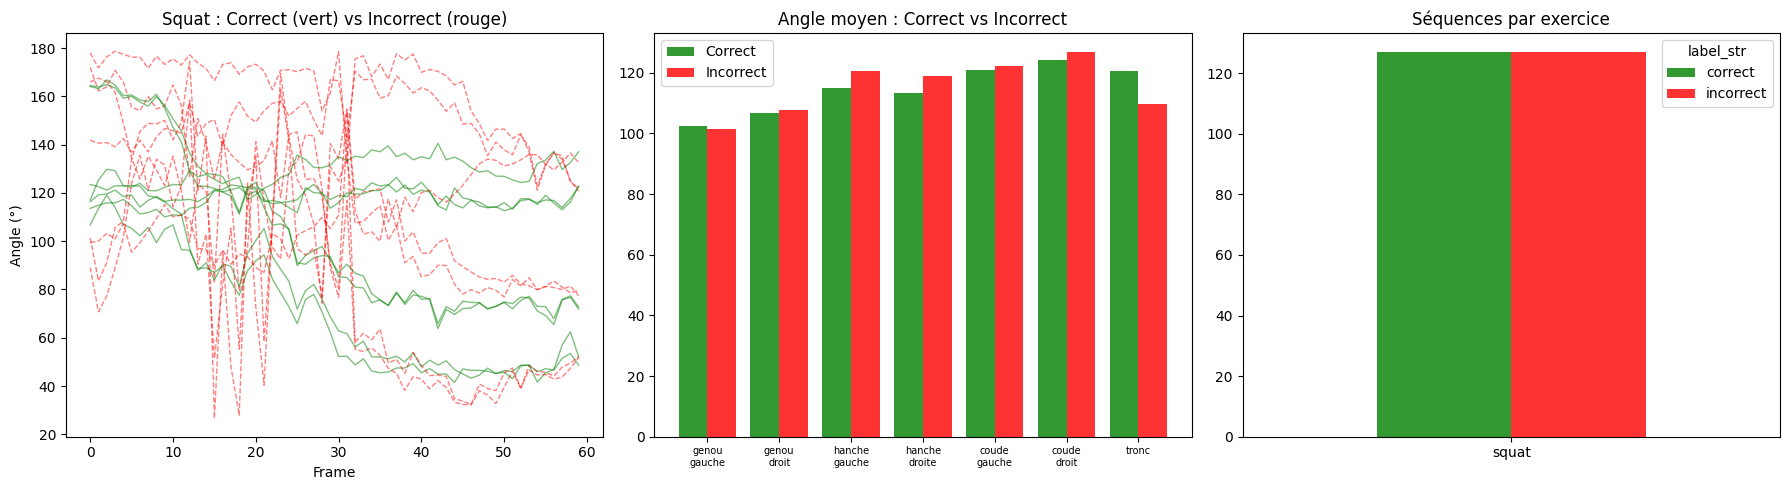

✅ EDA sauvegardée


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : séquence correcte vs incorrecte
idx_c = meta[(meta.exercise=='squat') & (meta.label==0)].index[0]
idx_i = meta[(meta.exercise=='squat') & (meta.label==1)].index[0]
for j in range(7):
    axes[0].plot(X[idx_c, :, j], color='green', alpha=0.5, lw=1)
    axes[0].plot(X[idx_i, :, j], color='red',   alpha=0.5, lw=1, linestyle='--')
axes[0].set_title('Squat : Correct (vert) vs Incorrect (rouge)')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Angle (°)')

# Graphique 2 : angle moyen par classe
X_mean  = X.mean(axis=1)
m_corr  = X_mean[y==0].mean(axis=0)
m_incr  = X_mean[y==1].mean(axis=0)
x_pos   = np.arange(7)
axes[1].bar(x_pos - 0.2, m_corr, 0.4, color='green', alpha=0.8, label='Correct')
axes[1].bar(x_pos + 0.2, m_incr, 0.4, color='red',   alpha=0.8, label='Incorrect')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([n.replace('_','\n') for n in ANGLE_NAMES], fontsize=7)
axes[1].set_title('Angle moyen : Correct vs Incorrect')
axes[1].legend()

# Graphique 3 : distribution par exercice
meta.groupby(['exercise','label_str']).size().unstack().plot(
    kind='bar', ax=axes[2], color=['green','red'], alpha=0.8
)
axes[2].set_title('Séquences par exercice')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{BASE}/results/eda_jour1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA sauvegardée")


In [23]:
np.save(f'{BASE}/processed/X.npy',    X_norm)
np.save(f'{BASE}/processed/y.npy',    y)
meta.to_csv(f'{BASE}/processed/meta.csv', index=False)
with open(f'{BASE}/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Fichiers sauvegardés dans /content/fitness_data/processed/")
print(f"   X.npy      : {X_norm.shape}")
print(f"   y.npy      : {y.shape}")
print(f"   meta.csv   : {len(meta)} lignes")
print(f"   scaler.pkl : StandardScaler (7 features)")


✅ Fichiers sauvegardés dans /content/fitness_data/processed/
   X.npy      : (254, 60, 7)
   y.npy      : (254,)
   meta.csv   : 254 lignes
   scaler.pkl : StandardScaler (7 features)


#Jour 2 — Entraînement du BiLSTM


In [24]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Imports OK')
print(f'Device : {DEVICE}')


Imports OK
Device : cuda


In [25]:

N, T, F = X.shape  # nb_sequences, 60 frames, 7 angles

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.167, random_state=42, stratify=y_temp
)

print(f'Split effectue :')
print(f'  Train : {len(X_train):4d} sequences ({len(X_train)/N*100:.0f}%)')
print(f'  Val   : {len(X_val):4d} sequences ({len(X_val)/N*100:.0f}%)')
print(f'  Test  : {len(X_test):4d} sequences ({len(X_test)/N*100:.0f}%)')


Split effectue :
  Train :  189 sequences (74%)
  Val   :   39 sequences (15%)
  Test  :   26 sequences (10%)


In [26]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.167, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape[0]} sequences")
print(f"Val   : {X_val.shape[0]} sequences")
print(f"Test  : {X_test.shape[0]} sequences")

Train : 189 sequences
Val   : 39 sequences
Test  : 26 sequences


In [27]:

class PoseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 16

train_loader = DataLoader(PoseDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(PoseDataset(X_val,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(PoseDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Batches train : {len(train_loader)}')
print(f'Batches val   : {len(val_loader)}')

Batches train : 12
Batches val   : 3


In [28]:
class PoseBiLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=128,
                 num_layers=2, num_classes=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0
        )

        self.norm    = nn.LayerNorm(hidden_size * 2)
        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)      # (batch, 60, 256)
        out    = out[:, -1, :]     # derniere frame uniquement (batch, 256)
        out    = self.norm(out)
        out    = self.dropout(out)
        return self.fc(out)        # (batch, 2)


model = PoseBiLSTM().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parametres total : {total_params:,}')
print(model)

Parametres total : 552,642
PoseBiLSTM(
  (lstm): LSTM(7, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5)

In [30]:

EPOCHS       = 60
best_val_acc = 0.0
history      = {'train_loss': [], 'val_loss': [],
                'train_acc':  [], 'val_acc':  []}

BASE = '/content/fitness_data'
import os
os.makedirs(f'{BASE}/results', exist_ok=True)

for epoch in range(EPOCHS):

    # -- TRAIN --
    model.train()
    train_loss, train_correct = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item()
        train_correct += (out.argmax(1) == yb).sum().item()

    train_loss /= len(train_loader)
    train_acc   = train_correct / len(X_train)

    # -- VAL --
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out        = model(xb)
            val_loss  += criterion(out, yb).item()
            val_correct += (out.argmax(1) == yb).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(X_val)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f'{BASE}/processed/model.pt')

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
              f'train_loss={train_loss:.4f}  train_acc={train_acc:.3f} | '
              f'val_loss={val_loss:.4f}  val_acc={val_acc:.3f}')

print(f'\nMeilleur val_acc : {best_val_acc:.4f}')
print(f'model.pt sauvegarde')


Epoch  10/60 | train_loss=0.6116  train_acc=0.667 | val_loss=0.6360  val_acc=0.667
Epoch  20/60 | train_loss=0.4054  train_acc=0.799 | val_loss=0.4918  val_acc=0.795
Epoch  30/60 | train_loss=0.3763  train_acc=0.836 | val_loss=0.3633  val_acc=0.821
Epoch  40/60 | train_loss=0.2284  train_acc=0.910 | val_loss=0.4690  val_acc=0.795
Epoch  50/60 | train_loss=0.1805  train_acc=0.921 | val_loss=0.5424  val_acc=0.846
Epoch  60/60 | train_loss=0.1451  train_acc=0.947 | val_loss=0.6188  val_acc=0.846

Meilleur val_acc : 0.8462
model.pt sauvegarde


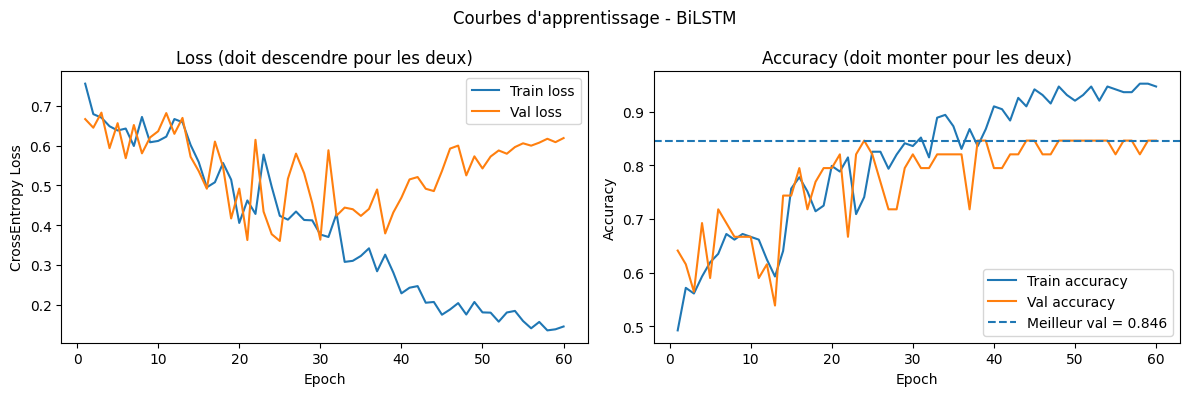

training_curves.png sauvegarde


In [31]:

ep = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ep, history['train_loss'], label='Train loss')
ax1.plot(ep, history['val_loss'],   label='Val loss')
ax1.set_title('Loss (doit descendre pour les deux)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('CrossEntropy Loss')
ax1.legend()

ax2.plot(ep, history['train_acc'], label='Train accuracy')
ax2.plot(ep, history['val_acc'],   label='Val accuracy')
ax2.axhline(y=best_val_acc, linestyle='--',
            label=f'Meilleur val = {best_val_acc:.3f}')
ax2.set_title('Accuracy (doit monter pour les deux)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.suptitle('Courbes d\'apprentissage - BiLSTM')
plt.tight_layout()
plt.savefig(f'{BASE}/results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('training_curves.png sauvegarde')


In [32]:
model.load_state_dict(torch.load(f'{BASE}/processed/model.pt'))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        out   = model(xb.to(DEVICE))
        probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print('=' * 50)
print('RESULTATS FINAUX - TEST SET')
print('=' * 50)
print(classification_report(all_labels, all_preds,
                             target_names=['Correct (0)', 'Incorrect (1)']))
print(f'AUC-ROC : {roc_auc_score(all_labels, all_probs):.4f}')

RESULTATS FINAUX - TEST SET
               precision    recall  f1-score   support

  Correct (0)       0.67      0.77      0.71        13
Incorrect (1)       0.73      0.62      0.67        13

     accuracy                           0.69        26
    macro avg       0.70      0.69      0.69        26
 weighted avg       0.70      0.69      0.69        26

AUC-ROC : 0.6509


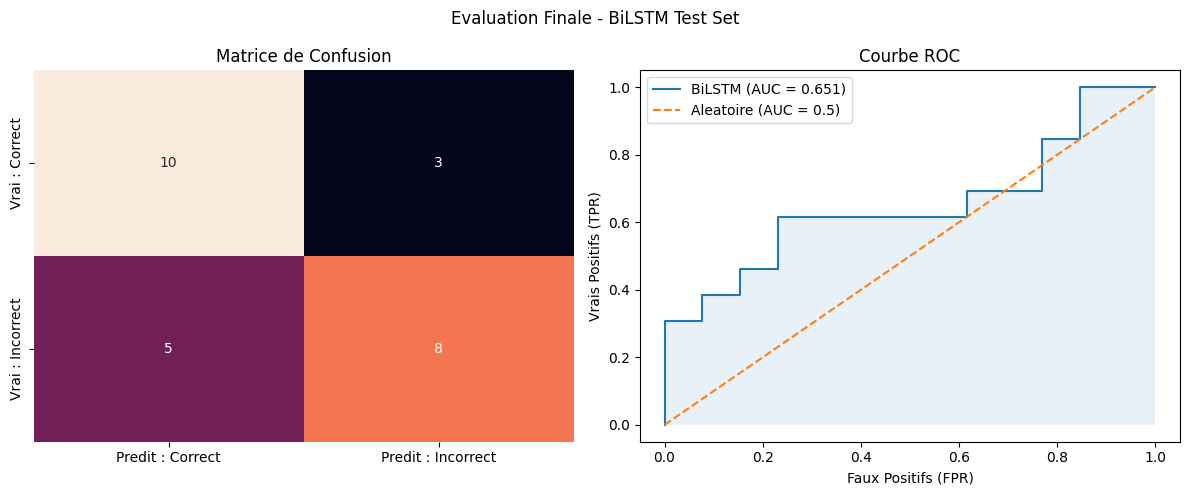

evaluation.png sauvegarde


In [33]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=ax1,
            xticklabels=['Predit : Correct', 'Predit : Incorrect'],
            yticklabels=['Vrai : Correct',   'Vrai : Incorrect'],
            cbar=False)
ax1.set_title('Matrice de Confusion')

# Courbe ROC
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_val     = roc_auc_score(all_labels, all_probs)
ax2.plot(fpr, tpr, label=f'BiLSTM (AUC = {auc_val:.3f})')
ax2.plot([0, 1], [0, 1], linestyle='--', label='Aleatoire (AUC = 0.5)')
ax2.fill_between(fpr, tpr, alpha=0.1)
ax2.set_title('Courbe ROC')
ax2.set_xlabel('Faux Positifs (FPR)')
ax2.set_ylabel('Vrais Positifs (TPR)')
ax2.legend()

plt.suptitle('Evaluation Finale - BiLSTM Test Set')
plt.tight_layout()
plt.savefig(f'{BASE}/results/evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('evaluation.png sauvegarde')


In [34]:
#  Resume Jour 2
acc_test = np.mean(all_preds == all_labels)
auc_test = roc_auc_score(all_labels, all_probs)

print()
print('=' * 50)
print('JOUR 2 TERMINE')
print('=' * 50)
print(f'  Test Accuracy : {acc_test:.3f}  ({acc_test*100:.1f}%)')
print(f'  AUC-ROC       : {auc_test:.3f}')
print()
print('  Fichiers crees :')
print(f'    model.pt             -> {BASE}/processed/')
print(f'    training_curves.png  -> {BASE}/results/')
print(f'    evaluation.png       -> {BASE}/results/')
print()
print('  Prochain : Jour 3 — Feedback localise par joint')


JOUR 2 TERMINE
  Test Accuracy : 0.692  (69.2%)
  AUC-ROC       : 0.651

  Fichiers crees :
    model.pt             -> /content/fitness_data/processed/
    training_curves.png  -> /content/fitness_data/results/
    evaluation.png       -> /content/fitness_data/results/

  Prochain : Jour 3 — Feedback localise par joint


#Jour 3 — Feedback localise par joint

In [35]:
import shap
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/fitness_data'

ANGLE_NAMES = [
    'genou_gauche', 'genou_droit',
    'hanche_gauche', 'hanche_droite',
    'coude_gauche', 'coude_droit',
    'tronc'
]

# Message feedback par joint
FEEDBACK = {
    'genou_gauche'  : 'Genou gauche en valgus — ramene le genou vers l\'avant',
    'genou_droit'   : 'Genou droit en valgus — ramene le genou vers l\'avant',
    'hanche_gauche' : 'Hanche gauche affaissee — contracte les fessiers',
    'hanche_droite' : 'Hanche droite affaissee — contracte les fessiers',
    'coude_gauche'  : 'Coude gauche mal positionne — serre les coudes',
    'coude_droit'   : 'Coude droit mal positionne — serre les coudes',
    'tronc'         : 'Tronc trop penche — garde le dos droit',
}

print('Imports OK')

Imports OK


In [36]:
#Recharger modele

model.load_state_dict(torch.load(f'{BASE}/processed/model.pt',
                                  map_location=DEVICE))
model.eval()

print(f'Modele charge')
print(f'Test set        : {X_test.shape[0]} sequences')
print(f'Incorrectes     : {(y_test == 1).sum()}')



Modele charge
Test set        : 26 sequences
Incorrectes     : 13


In [40]:
#  Gradient Attribution (remplacement SHAP)

incorrect_idx = np.where(y_test == 1)[0]
model.train()
X_incorrect_np = X_test[incorrect_idx]
X_inc = torch.FloatTensor(X_incorrect_np).to(DEVICE)
X_inc.requires_grad_(True)

# Passe forward
out   = model(X_inc)
# Score de la classe 1 (incorrect) pour toutes les sequences
score = out[:, 1].sum()
# Backprop pour calculer le gradient par rapport a chaque angle
score.backward()

# Gradients shape : (N, 60, 7)
grads = X_inc.grad.abs().cpu().detach().numpy()

# Moyenne sur les 60 frames -> (N, 7)
shap_mean = grads.mean(axis=1)

# Normalisation en %
shap_norm = shap_mean / shap_mean.sum(axis=1, keepdims=True)

# Joint dominant par sequence
dominant_joint = shap_norm.argmax(axis=1)
model.eval()
print(f'Gradients shape : {grads.shape}')
print()
print('Contribution moyenne de chaque angle :')
print()
for j, name in enumerate(ANGLE_NAMES):
    contrib = shap_norm[:, j].mean() * 100
    bar     = '#' * int(contrib / 2)
    print(f'  {name:<18} : {contrib:5.1f}%  {bar}')


Gradients shape : (13, 60, 7)

Contribution moyenne de chaque angle :

  genou_gauche       :  16.4%  ########
  genou_droit        :  11.7%  #####
  hanche_gauche      :  13.9%  ######
  hanche_droite      :   9.8%  ####
  coude_gauche       :  13.6%  ######
  coude_droit        :  15.5%  #######
  tronc              :  19.1%  #########


In [41]:
#  Feedback par sequence

with open(f'{BASE}/processed/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print('Exemples de feedback genere automatiquement :')
print('=' * 55)

for i in range(min(8, len(incorrect_idx))):
    seq_idx    = incorrect_idx[i]
    joint_idx  = dominant_joint[i]
    joint_name = ANGLE_NAMES[joint_idx]
    contrib    = shap_norm[i, joint_idx] * 100

    # Angle moyen normalise sur la sequence
    angle_norm  = X_test[seq_idx, :, joint_idx].mean()
    # Inverser le StandardScaler pour retrouver les degres
    angle_reel  = angle_norm * scaler.scale_[joint_idx] + scaler.mean_[joint_idx]

    exercise = meta.iloc[seq_idx]['exercise'] if seq_idx < len(meta) else 'inconnu'

    print(f'Sequence {i+1} | Exercice : {exercise}')
    print(f'  Joint responsable : {joint_name} ({contrib:.1f}% de contribution)')
    print(f'  Angle moyen       : {angle_reel:.1f} deg')
    print(f'  Feedback          : {FEEDBACK[joint_name]}')
    print()




Exemples de feedback genere automatiquement :
Sequence 1 | Exercice : squat
  Joint responsable : coude_gauche (18.9% de contribution)
  Angle moyen       : 5900.2 deg
  Feedback          : Coude gauche mal positionne — serre les coudes

Sequence 2 | Exercice : squat
  Joint responsable : coude_gauche (17.8% de contribution)
  Angle moyen       : 2377.2 deg
  Feedback          : Coude gauche mal positionne — serre les coudes

Sequence 3 | Exercice : squat
  Joint responsable : tronc (20.4% de contribution)
  Angle moyen       : 1936.7 deg
  Feedback          : Tronc trop penche — garde le dos droit

Sequence 4 | Exercice : squat
  Joint responsable : tronc (25.1% de contribution)
  Angle moyen       : 3030.9 deg
  Feedback          : Tronc trop penche — garde le dos droit

Sequence 5 | Exercice : squat
  Joint responsable : genou_gauche (19.9% de contribution)
  Angle moyen       : 4789.9 deg
  Feedback          : Genou gauche en valgus — ramene le genou vers l'avant

Sequence 6 | Exer

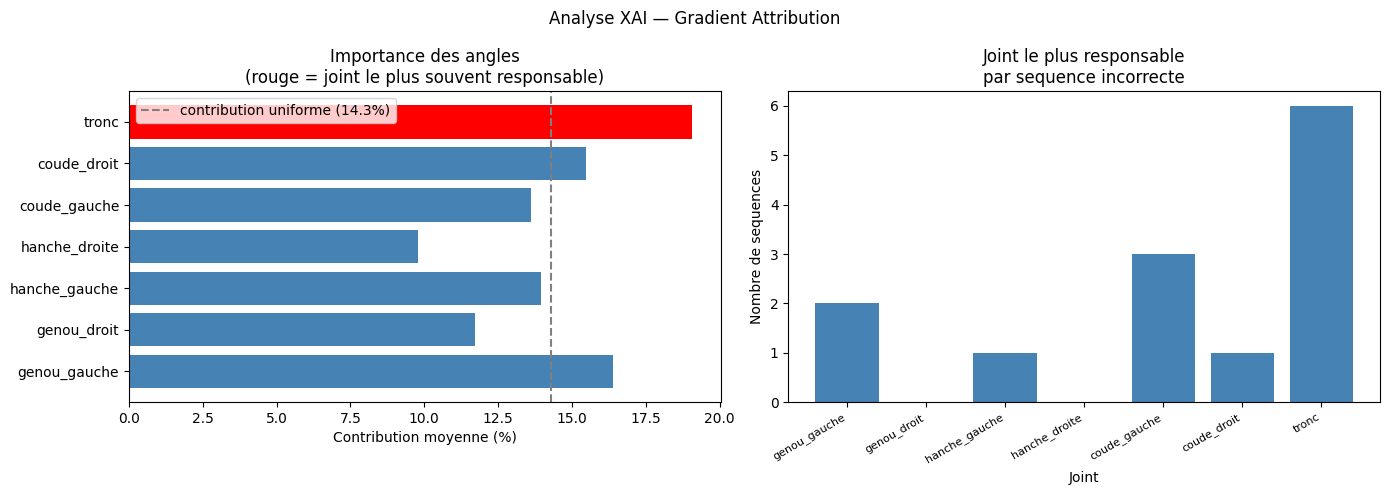

xai_contributions.png sauvegarde


In [42]:
# Heatmap globale des contributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : contribution moyenne
mean_contrib = shap_norm.mean(axis=0) * 100
colors = ['red' if c == mean_contrib.max() else 'steelblue'
          for c in mean_contrib]

axes[0].barh(ANGLE_NAMES, mean_contrib, color=colors)
axes[0].set_xlabel('Contribution moyenne (%)')
axes[0].set_title('Importance des angles\n(rouge = joint le plus souvent responsable)')
axes[0].axvline(x=100/7, color='gray', linestyle='--', label='contribution uniforme (14.3%)')
axes[0].legend()

# Graphique 2 : joint dominant par sequence
joint_counts = np.bincount(dominant_joint, minlength=7)
axes[1].bar(ANGLE_NAMES, joint_counts, color='steelblue')
axes[1].set_xlabel('Joint')
axes[1].set_ylabel('Nombre de sequences')
axes[1].set_title('Joint le plus responsable\npar sequence incorrecte')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Analyse XAI — Gradient Attribution')
plt.tight_layout()
plt.savefig(f'{BASE}/results/xai_contributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('xai_contributions.png sauvegarde')


Exercices presents dans les incorrectes : ['squat']


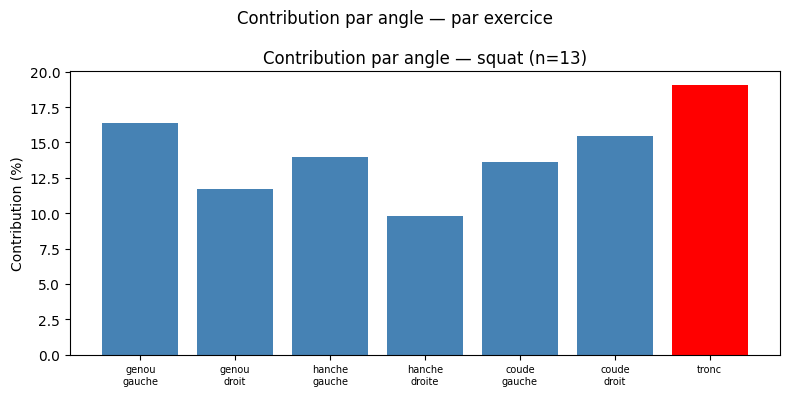

xai_par_exercice.png sauvegarde


In [43]:
# Analyse par exercice
exercises_present = []
for exercise in meta['exercise'].unique():
    ex_mask = np.array([
        meta.iloc[idx]['exercise'] == exercise
        for idx in incorrect_idx
        if idx < len(meta)
    ])
    if ex_mask.sum() > 0:
        exercises_present.append((exercise, ex_mask))

print(f'Exercices presents dans les incorrectes : {[e[0] for e in exercises_present]}')

if len(exercises_present) == 1:
    # Un seul exercice -> pas de comparaison possible
    exercise, ex_mask = exercises_present[0]
    ex_contrib  = shap_norm[ex_mask].mean(axis=0) * 100
    bar_colors  = ['red' if j == ex_contrib.argmax() else 'steelblue' for j in range(7)]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(7), ex_contrib, color=bar_colors)
    ax.set_xticks(range(7))
    ax.set_xticklabels([n.replace('_', '\n') for n in ANGLE_NAMES], fontsize=7)
    ax.set_title(f'Contribution par angle — {exercise} (n={ex_mask.sum()})')
    ax.set_ylabel('Contribution (%)')

else:
    fig, axes = plt.subplots(1, len(exercises_present), figsize=(15, 4))
    for i, (exercise, ex_mask) in enumerate(exercises_present):
        ex_contrib = shap_norm[ex_mask].mean(axis=0) * 100
        bar_colors = ['red' if j == ex_contrib.argmax() else 'steelblue' for j in range(7)]
        axes[i].bar(range(7), ex_contrib, color=bar_colors)
        axes[i].set_xticks(range(7))
        axes[i].set_xticklabels([n.replace('_', '\n') for n in ANGLE_NAMES], fontsize=7)
        axes[i].set_title(f'{exercise}\n(n={ex_mask.sum()})')
        axes[i].set_ylabel('Contribution (%)')

plt.suptitle('Contribution par angle — par exercice')
plt.tight_layout()
plt.savefig(f'{BASE}/results/xai_par_exercice.png', dpi=150, bbox_inches='tight')
plt.show()
print('xai_par_exercice.png sauvegarde')

In [44]:
#  Resume Jour 3
print('=' * 50)
print('JOUR 3 TERMINE')
print('=' * 50)
print()
print('Ce qu\'on a fait :')
print('  1. Calcule les SHAP values sur les sequences incorrectes')
print('  2. Identifie le joint responsable par sequence')
print('  3. Genere un feedback texte actionnable par joint')
print('  4. Visualise les contributions par angle et par exercice')
print()
print('Fichiers crees :')
print(f'  xai_contributions.png  -> {BASE}/results/')
print(f'  xai_par_exercice.png   -> {BASE}/results/')
print()
print('Prochain : Jour 4 — Dashboard complet')

JOUR 3 TERMINE

Ce qu'on a fait :
  1. Calcule les SHAP values sur les sequences incorrectes
  2. Identifie le joint responsable par sequence
  3. Genere un feedback texte actionnable par joint
  4. Visualise les contributions par angle et par exercice

Fichiers crees :
  xai_contributions.png  -> /content/fitness_data/results/
  xai_par_exercice.png   -> /content/fitness_data/results/

Prochain : Jour 4 — Dashboard complet


# Jour 4 — Dashboard complet

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import pickle
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/fitness_data'

ANGLE_NAMES = [
    'genou_gauche', 'genou_droit',
    'hanche_gauche', 'hanche_droite',
    'coude_gauche', 'coude_droit',
    'tronc'
]

print('Imports OK')
print('Toutes les variables doivent etre en memoire depuis Jours 1-3 :')
print(f'  X           : {X.shape}')
print(f'  y           : {y.shape}')
print(f'  history     : {list(history.keys())}')
print(f'  all_preds   : {len(all_preds)} predictions')
print(f'  shap_norm   : {shap_norm.shape}')



Imports OK
Toutes les variables doivent etre en memoire depuis Jours 1-3 :
  X           : (254, 60, 7)
  y           : (254,)
  history     : ['train_loss', 'val_loss', 'train_acc', 'val_acc']
  all_preds   : 26 predictions
  shap_norm   : (13, 7)


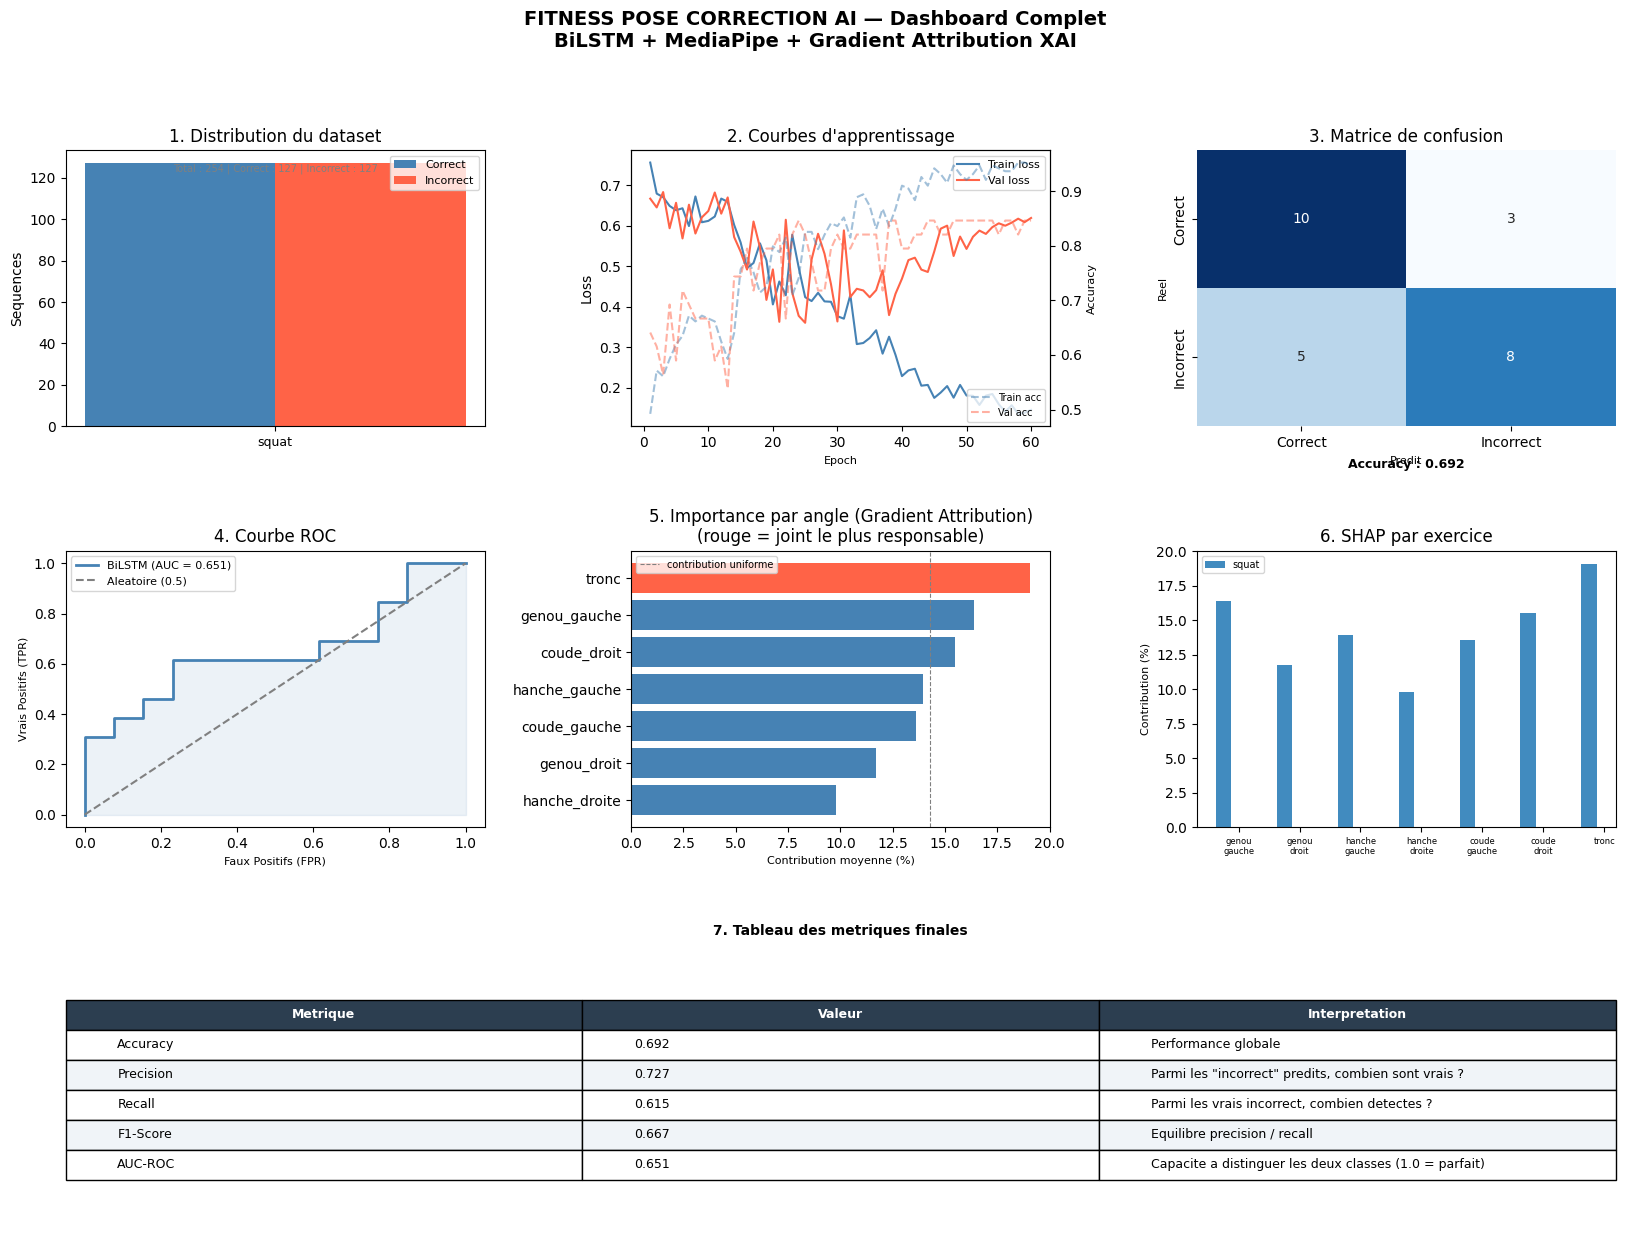

dashboard.png sauvegarde


In [46]:

# CELLULE 2 : Dashboard complet

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

#Graphique 1 : Distribution du dataset
ax1 = fig.add_subplot(gs[0, 0])

meta_counts = meta.groupby(['exercise', 'label_str']).size().unstack()
exercises   = meta_counts.index.tolist()
x_pos       = np.arange(len(exercises))
width       = 0.35

ax1.bar(x_pos - width/2, meta_counts['correct'],   width, label='Correct',   color='steelblue')
ax1.bar(x_pos + width/2, meta_counts['incorrect'], width, label='Incorrect', color='tomato')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(exercises, fontsize=9)
ax1.set_ylabel('Sequences')
ax1.set_title('1. Distribution du dataset')
ax1.legend(fontsize=8)

total    = len(y)
n_corr   = (y == 0).sum()
n_incorr = (y == 1).sum()
ax1.text(0.5, 0.95, f'Total : {total} | Correct : {n_corr} | Incorrect : {n_incorr}',
         transform=ax1.transAxes, ha='center', va='top', fontsize=7, color='gray')


# Graphique 2 : Courbes d'apprentissage
ax2 = fig.add_subplot(gs[0, 1])

ep = range(1, len(history['train_loss']) + 1)
ax2.plot(ep, history['train_loss'], label='Train loss', color='steelblue')
ax2.plot(ep, history['val_loss'],   label='Val loss',   color='tomato')
ax2.set_xlabel('Epoch', fontsize=8)
ax2.set_ylabel('Loss')
ax2.set_title('2. Courbes d\'apprentissage')
ax2.legend(fontsize=8)

ax2b = ax2.twinx()
ax2b.plot(ep, history['train_acc'], linestyle='--', color='steelblue', alpha=0.5, label='Train acc')
ax2b.plot(ep, history['val_acc'],   linestyle='--', color='tomato',    alpha=0.5, label='Val acc')
ax2b.set_ylabel('Accuracy', fontsize=8)
ax2b.legend(fontsize=7, loc='lower right')


#Graphique 3 : Matrice de confusion
ax3 = fig.add_subplot(gs[0, 2])

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=ax3,
            xticklabels=['Correct', 'Incorrect'],
            yticklabels=['Correct', 'Incorrect'],
            cbar=False, cmap='Blues')
ax3.set_xlabel('Predit', fontsize=8)
ax3.set_ylabel('Reel', fontsize=8)
ax3.set_title('3. Matrice de confusion')

acc = np.mean(np.array(all_preds) == np.array(all_labels))
ax3.text(0.5, -0.15, f'Accuracy : {acc:.3f}',
         transform=ax3.transAxes, ha='center', fontsize=9, fontweight='bold')


# Graphique 4 : Courbe ROC
ax4 = fig.add_subplot(gs[1, 0])

fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_val     = roc_auc_score(all_labels, all_probs)
ax4.plot(fpr, tpr, color='steelblue', lw=2, label=f'BiLSTM (AUC = {auc_val:.3f})')
ax4.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatoire (0.5)')
ax4.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax4.set_xlabel('Faux Positifs (FPR)', fontsize=8)
ax4.set_ylabel('Vrais Positifs (TPR)', fontsize=8)
ax4.set_title('4. Courbe ROC')
ax4.legend(fontsize=8)


#Graphique 5 : SHAP contributions globales
ax5 = fig.add_subplot(gs[1, 1])

mean_contrib = shap_norm.mean(axis=0) * 100
sorted_idx   = np.argsort(mean_contrib)
colors       = ['tomato' if i == sorted_idx[-1] else 'steelblue'
                for i in range(7)]
colors_sorted = [colors[i] for i in sorted_idx]

ax5.barh([ANGLE_NAMES[i] for i in sorted_idx], mean_contrib[sorted_idx],
         color=colors_sorted)
ax5.axvline(x=100/7, color='gray', linestyle='--', linewidth=0.8,
            label='contribution uniforme')
ax5.set_xlabel('Contribution moyenne (%)', fontsize=8)
ax5.set_title('5. Importance par angle (Gradient Attribution)\n(rouge = joint le plus responsable)')
ax5.legend(fontsize=7)


#  Graphique 6 : SHAP par exercice
ax6 = fig.add_subplot(gs[1, 2])

exercises_list = meta['exercise'].unique()
incorrect_idx  = np.where(y_test == 1)[0]

data_ex = []
for exercise in exercises_list:
    ex_mask = np.array([
        meta.iloc[idx]['exercise'] == exercise
        for idx in incorrect_idx
        if idx < len(meta)
    ])
    if ex_mask.sum() > 0:
        ex_contrib = shap_norm[ex_mask].mean(axis=0) * 100
        data_ex.append(ex_contrib)

data_ex = np.array(data_ex)
x_ex    = np.arange(7)
width   = 0.25

for i, exercise in enumerate(exercises_list):
    if i < len(data_ex):
        ax6.bar(x_ex + i * width, data_ex[i], width, label=exercise, alpha=0.85)

ax6.set_xticks(x_ex + width)
ax6.set_xticklabels([n.replace('_', '\n') for n in ANGLE_NAMES], fontsize=6)
ax6.set_ylabel('Contribution (%)', fontsize=8)
ax6.set_title('6. SHAP par exercice')
ax6.legend(fontsize=7)


#Graphique 7 : Metriques resume
ax7 = fig.add_subplot(gs[2, :])
ax7.axis('off')

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)

metriques = [
    ('Accuracy',  f'{acc:.3f}',     'Performance globale'),
    ('Precision', f'{precision:.3f}', 'Parmi les "incorrect" predits, combien sont vrais ?'),
    ('Recall',    f'{recall:.3f}',    'Parmi les vrais incorrect, combien detectes ?'),
    ('F1-Score',  f'{f1:.3f}',        'Equilibre precision / recall'),
    ('AUC-ROC',   f'{auc_val:.3f}',   'Capacite a distinguer les deux classes (1.0 = parfait)'),
]

col_labels = ['Metrique', 'Valeur', 'Interpretation']
table_data = [[m[0], m[1], m[2]] for m in metriques]

table = ax7.table(
    cellText    = table_data,
    colLabels   = col_labels,
    loc         = 'center',
    cellLoc     = 'left',
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

for j in range(3):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(metriques) + 1):
    bg = '#f0f4f8' if i % 2 == 0 else 'white'
    for j in range(3):
        table[i, j].set_facecolor(bg)

ax7.set_title('7. Tableau des metriques finales', fontsize=10, fontweight='bold', pad=12)


#  Titre general
fig.suptitle(
    'FITNESS POSE CORRECTION AI — Dashboard Complet\n'
      'BiLSTM + MediaPipe + Gradient Attribution XAI',
    fontsize=14, fontweight='bold', y=0.98
)

plt.savefig(f'{BASE}/results/dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('dashboard.png sauvegarde')




In [47]:

# CELLULE 3 : Resume Jour 4
print('=' * 50)
print('JOUR 4 TERMINE')
print('=' * 50)
print()
print('Done :')
print('  1. Assemble tous les resultats Jours 1-2-3')
print('  2. Cree un dashboard de 7 graphiques en une page')
print('  3. Ajoute un tableau de metriques synthetique')
print()
print('Fichier cree :')
print(f'  dashboard.png  -> {BASE}/results/')
print()
print('Prochain : Jour 5 — Comparaison de modeles')
print('  (LSTM vs GRU vs MLP vs Random Forest)')

JOUR 4 TERMINE

Done :
  1. Assemble tous les resultats Jours 1-2-3
  2. Cree un dashboard de 7 graphiques en une page
  3. Ajoute un tableau de metriques synthetique

Fichier cree :
  dashboard.png  -> /content/fitness_data/results/

Prochain : Jour 5 — Comparaison de modeles
  (LSTM vs GRU vs MLP vs Random Forest)


#Jour 5 — Comparaison de modeles

In [48]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.metrics import roc_auc_score, classification_report
from torch.utils.data import DataLoader
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/fitness_data'

# X_train, X_val, X_test, y_train, y_val, y_test
# train_loader, val_loader, test_loader

print('Imports OK')


Imports OK


In [49]:

class ModelLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=128, num_layers=2,
                 num_classes=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            bidirectional = False,
            dropout = dropout if num_layers > 1 else 0
        )
        self.norm    = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = out[:, -1, :]
        out    = self.norm(out)
        out    = self.dropout(out)
        return self.fc(out)


class ModelBiLSTM(nn.Module):
    def __init__(self, input_size=7, hidden_size=128, num_layers=2,
                 num_classes=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout = dropout if num_layers > 1 else 0
        )
        self.norm    = nn.LayerNorm(hidden_size * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = out[:, -1, :]
        out    = self.norm(out)
        out    = self.dropout(out)
        return self.fc(out)


class ModelGRU(nn.Module):
    def __init__(self, input_size=7, hidden_size=128, num_layers=2,
                 num_classes=2, dropout=0.3):
        super().__init__()
        # GRU = Gated Recurrent Unit
        # Similaire au LSTM mais avec seulement 2 portes (reset + update)
        # au lieu de 3 (forget + input + output)
        # → moins de parametres, plus rapide, souvent aussi performant
        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            bidirectional = True,
            dropout = dropout if num_layers > 1 else 0
        )
        self.norm    = nn.LayerNorm(hidden_size * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        out    = out[:, -1, :]
        out    = self.norm(out)
        out    = self.dropout(out)
        return self.fc(out)


class ModelMLP(nn.Module):
    def __init__(self, input_size=60*7, num_classes=2, dropout=0.3):
        super().__init__()
        # MLP = Multi-Layer Perceptron
        # Pas de memoire temporelle — voit la sequence comme
        # un vecteur plat de 420 valeurs (60 frames x 7 angles)
        # C'est la baseline : que vaut-on sans LSTM ?
        self.fc = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)  # aplatir (batch, 60*7)
        return self.fc(x)


MODELS = {
    'LSTM'   : ModelLSTM(),
    'BiLSTM' : ModelBiLSTM(),
    'GRU'    : ModelGRU(),
    'MLP'    : ModelMLP(),
}

print('Modeles definis :')
for name, m in MODELS.items():
    n_params = sum(p.numel() for p in m.parameters())
    print(f'  {name:<8} : {n_params:>8,} parametres')



Modeles definis :
  LSTM     :  210,882 parametres
  BiLSTM   :  552,642 parametres
  GRU      :  418,754 parametres
  MLP      :  149,058 parametres


In [50]:
def train_model(model, train_loader, val_loader, epochs=40, lr=1e-3):
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    best_val_acc = 0.0
    best_weights = None
    start        = time.time()

    for epoch in range(epochs):

        # TRAIN
        model.train()
        train_correct = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_correct += (out.argmax(1) == yb).sum().item()

        # VAL
        model.eval()
        val_correct, val_loss = 0, 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out        = model(xb)
                val_loss  += criterion(out, yb).item()
                val_correct += (out.argmax(1) == yb).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

    duration = time.time() - start
    model.load_state_dict(best_weights)
    return model, best_val_acc, duration


def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            out   = model(xb.to(DEVICE))
            probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
            all_probs.extend(probs)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc = np.mean(all_preds == all_labels)
    auc = roc_auc_score(all_labels, all_probs)
    return acc, auc

print('Fonctions train_model et evaluate_model definies')


Fonctions train_model et evaluate_model definies


In [56]:
# Entrainement de tous les modeles
#   - 40 epochs (moins que Jour 2 pour aller plus vite)
#   - lr = 1e-3
#   - memes train/val/test sets

EPOCHS_PAR_MODELE = {
    'LSTM'   : 40,
    'BiLSTM' : 60,
    'GRU'    : 40,
    'MLP'    : 40,
}
results     = {}

for name, model_instance in MODELS.items():
    print(f'Entrainement {name}...', end=' ', flush=True)
    trained_model, best_val, duration = train_model(
    model_instance, train_loader, val_loader, epochs=EPOCHS_PAR_MODELE[name])
    test_acc, test_auc = evaluate_model(trained_model, test_loader)
    n_params = sum(p.numel() for p in trained_model.parameters())

    results[name] = {
        'val_acc'   : best_val,
        'test_acc'  : test_acc,
        'auc'       : test_auc,
        'params'    : n_params,
        'temps_s'   : duration,
    }
    print(f'val={best_val:.3f}  test={test_acc:.3f}  AUC={test_auc:.3f}  ({duration:.0f}s)')

print()
print('Entrainement termine')



Entrainement LSTM... val=0.923  test=0.654  AUC=0.781  (4s)
Entrainement BiLSTM... val=0.872  test=0.731  AUC=0.876  (4s)
Entrainement GRU... val=0.923  test=0.769  AUC=0.870  (4s)
Entrainement MLP... val=0.513  test=0.500  AUC=0.485  (2s)

Entrainement termine


In [57]:
#tableau comparatif
df = pd.DataFrame(results).T
df['params_k'] = (df['params'] / 1000).round(1)
df = df[['test_acc', 'auc', 'params_k', 'temps_s']]
df.columns = ['Test Accuracy', 'AUC-ROC', 'Params (k)', 'Temps (s)']
df = df.sort_values('Test Accuracy', ascending=False)

print('=' * 60)
print('TABLEAU COMPARATIF DES MODELES')
print('=' * 60)
print(df.round(3).to_string())
print()
print(f'Meilleur accuracy : {df["Test Accuracy"].idxmax()}')
print(f'Meilleur AUC      : {df["AUC-ROC"].idxmax()}')
print(f'Plus leger        : {df["Params (k)"].idxmin()}')
print(f'Plus rapide       : {df["Temps (s)"].idxmin()}')



TABLEAU COMPARATIF DES MODELES
        Test Accuracy  AUC-ROC  Params (k)  Temps (s)
GRU             0.769    0.870       418.8      3.745
BiLSTM          0.731    0.876       552.6      3.835
LSTM            0.654    0.781       210.9      4.056
MLP             0.500    0.485       149.1      1.757

Meilleur accuracy : GRU
Meilleur AUC      : BiLSTM
Plus leger        : MLP
Plus rapide       : MLP


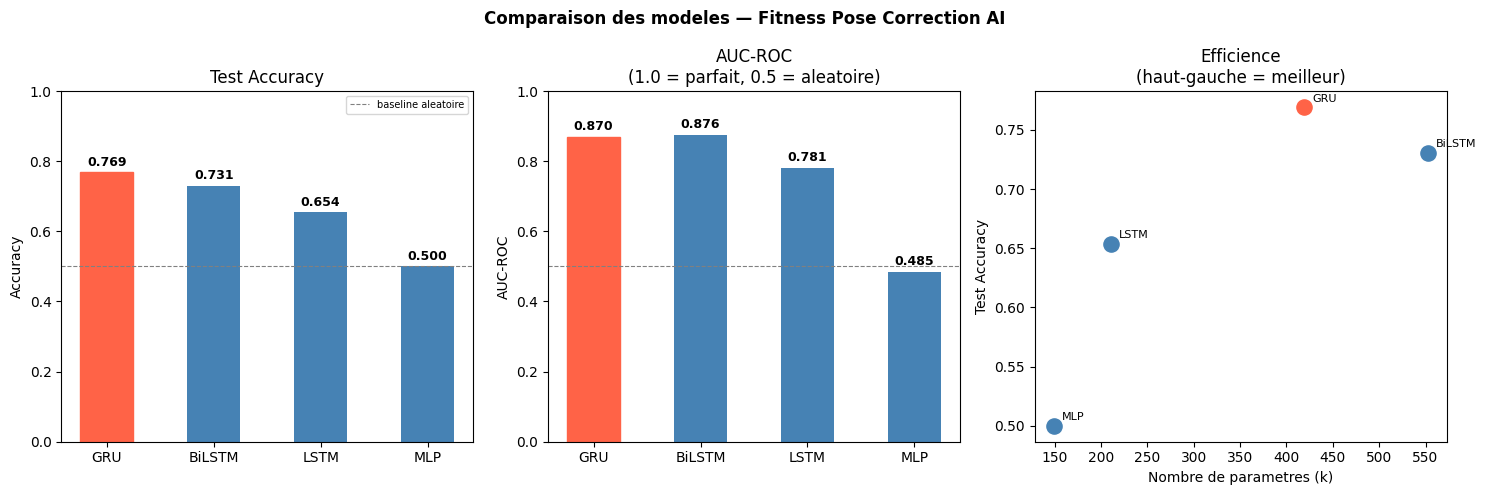

comparaison_modeles.png sauvegarde


In [58]:
#  Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names = df.index.tolist()
x           = np.arange(len(model_names))
width       = 0.5

# Graphique 1 : Test Accuracy
bars1 = axes[0].bar(x, df['Test Accuracy'], width, color='steelblue')
bars1[0].set_color('tomato')   # meilleur en rouge
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Test Accuracy')
axes[0].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8, label='baseline aleatoire')
axes[0].legend(fontsize=7)
for bar, val in zip(bars1, df['Test Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Graphique 2 : AUC-ROC
bars2 = axes[1].bar(x, df['AUC-ROC'], width, color='steelblue')
bars2[0].set_color('tomato')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC\n(1.0 = parfait, 0.5 = aleatoire)')
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8)
for bar, val in zip(bars2, df['AUC-ROC']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Graphique 3 : Params vs Accuracy (efficience)
for name in model_names:
    color = 'tomato' if name == df['Test Accuracy'].idxmax() else 'steelblue'
    axes[2].scatter(results[name]['params']/1000, results[name]['test_acc'],
                    s=120, color=color, zorder=3)
    axes[2].annotate(name,
                     (results[name]['params']/1000, results[name]['test_acc']),
                     textcoords='offset points', xytext=(6, 4), fontsize=8)

axes[2].set_xlabel('Nombre de parametres (k)')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_title('Efficience\n(haut-gauche = meilleur)')

plt.suptitle('Comparaison des modeles — Fitness Pose Correction AI', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE}/results/comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('comparaison_modeles.png sauvegarde')



In [59]:

#  Resume Jour 5
print('=' * 50)
print('JOUR 5 TERMINE')
print('=' * 50)
print()
print('done')
print('  1. Defini 4 architectures : LSTM, BiLSTM, GRU, MLP')
print('  2. Entraine chaque modele sur les memes donnees')
print('  3. Compare accuracy, AUC, params, temps')
print('  4. Visualise les resultats')
print()
print('Fichier cree :')
print(f'  comparaison_modeles.png  -> {BASE}/results/')
print()
print('Prochain : Jour 6 — Ablation Study')
print('  (impact de chaque choix architectural)')


JOUR 5 TERMINE

done
  1. Defini 4 architectures : LSTM, BiLSTM, GRU, MLP
  2. Entraine chaque modele sur les memes donnees
  3. Compare accuracy, AUC, params, temps
  4. Visualise les resultats

Fichier cree :
  comparaison_modeles.png  -> /content/fitness_data/results/

Prochain : Jour 6 — Ablation Study
  (impact de chaque choix architectural)


#Jour 6 — Ablation Study

In [60]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.metrics import roc_auc_score
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

BASE   = '/content/fitness_data'

print('Imports OK')


Imports OK


In [61]:

# Modele BiLSTM generique (parametrable)

# On cree une version flexible du BiLSTM ou on peut changer :
#   - hidden_size  : taille de la memoire interne
#   - num_layers   : nombre de couches empilees
#   - dropout      : taux de regularisation
#   - seq_len      : longueur de la sequence (pour le MLP flat)
#   - bidirectional: True/False

class BiLSTMFlex(nn.Module):
    def __init__(self, input_size=7, hidden_size=128, num_layers=2,
                 num_classes=2, dropout=0.3, bidirectional=True):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = bidirectional,
            dropout       = dropout if num_layers > 1 else 0
        )
        out_size = hidden_size * 2 if bidirectional else hidden_size
        self.norm    = nn.LayerNorm(out_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(out_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = out[:, -1, :]
        out    = self.norm(out)
        out    = self.dropout(out)
        return self.fc(out)

print('BiLSTMFlex defini')


BiLSTMFlex defini


In [62]:

# Fonctions utilitaires


class PoseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te, batch_size=16):
    return (
        DataLoader(PoseDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True),
        DataLoader(PoseDataset(X_v,  y_v),  batch_size=batch_size, shuffle=False),
        DataLoader(PoseDataset(X_te, y_te), batch_size=batch_size, shuffle=False),
    )


def train_eval(model, tr_loader, v_loader, te_loader, epochs=50, lr=1e-3):
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    best_val, best_w = 0.0, None

    for epoch in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in v_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out        = model(xb)
                val_loss  += criterion(out, yb).item()
                val_correct += (out.argmax(1) == yb).sum().item()
        val_acc = val_correct / len(v_loader.dataset)
        scheduler.step(val_loss)
        if val_acc > best_val:
            best_val = val_acc
            best_w   = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_w)
    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for xb, yb in te_loader:
            out = model(xb.to(DEVICE))
            probs.extend(torch.softmax(out, 1)[:, 1].cpu().numpy())
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())

    acc = np.mean(np.array(preds) == np.array(labels))
    auc = roc_auc_score(labels, probs)
    return acc, auc


# Loaders standards (seq_len=60, 7 angles)
tr_loader, v_loader, te_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test)

print('Fonctions et loaders prets')


Fonctions et loaders prets


In [68]:

# CELLULE 4 : Ablation Study

# Variations testees :
#   1. Reference         : configuration originale
#   2. hidden=64         : memoire reduite de moitie
#   3. hidden=256        : memoire doublée
#   4. 1 couche          : moins de profondeur
#   5. pas de dropout    : sans regularisation
#   6. unidirectionnel   : sans bidirectionnalite
configs = {
    'Reference (hidden=128, layers=2, drop=0.3, bidir)' : {
        'hidden_size': 128, 'num_layers': 2,
        'dropout': 0.3, 'bidirectional': True, 'epochs': 60
    },
    'hidden=64 (memoire reduite)' : {
        'hidden_size': 64, 'num_layers': 2,
        'dropout': 0.3, 'bidirectional': True, 'epochs': 50
    },
    'hidden=256 (memoire augmentee)' : {
        'hidden_size': 256, 'num_layers': 2,
        'dropout': 0.3, 'bidirectional': True, 'epochs': 50
    },
    '1 couche (moins profond)' : {
        'hidden_size': 128, 'num_layers': 1,
        'dropout': 0.3, 'bidirectional': True, 'epochs': 50
    },
    'dropout=0 (sans regularisation)' : {
        'hidden_size': 128, 'num_layers': 2,
        'dropout': 0.0, 'bidirectional': True, 'epochs': 50
    },
    'unidirectionnel (sans bidir)' : {
        'hidden_size': 128, 'num_layers': 2,
        'dropout': 0.3, 'bidirectional': False, 'epochs': 50
    },
}

ablation_results = {}

for config_name, params in configs.items():
    print(f'Test : {config_name}... ', end='', flush=True)
    epochs = params.pop('epochs', 50)
    m      = BiLSTMFlex(**params)
    acc, auc = train_eval(m, tr_loader, v_loader, te_loader, epochs=epochs)
    n_params = sum(p.numel() for p in m.parameters())
    ablation_results[config_name] = {
        'accuracy': acc, 'auc': auc, 'params': n_params
    }
    print(f'acc={acc:.3f}  auc={auc:.3f}')

print()
print('Ablation study terminee')



Test : Reference (hidden=128, layers=2, drop=0.3, bidir)... acc=0.731  auc=0.858
Test : hidden=64 (memoire reduite)... acc=0.769  auc=0.864
Test : hidden=256 (memoire augmentee)... acc=0.692  auc=0.811
Test : 1 couche (moins profond)... acc=0.577  auc=0.639
Test : dropout=0 (sans regularisation)... acc=0.692  auc=0.686
Test : unidirectionnel (sans bidir)... acc=0.808  auc=0.811

Ablation study terminee


In [69]:
#Tableau des resultats
df_ab = pd.DataFrame(ablation_results).T
df_ab = df_ab[['accuracy', 'auc', 'params']]
df_ab['params_k'] = (df_ab['params'] / 1000).round(1)
df_ab = df_ab.drop(columns='params')
df_ab.columns = ['Accuracy', 'AUC-ROC', 'Params (k)']

print('=' * 70)
print('ABLATION STUDY — RESULTATS')
print('=' * 70)
print(df_ab.round(3).to_string())
print()

# Identifier la reference
ref_acc = ablation_results[list(configs.keys())[0]]['accuracy']
ref_auc = ablation_results[list(configs.keys())[0]]['auc']
print(f'Reference : Accuracy={ref_acc:.3f}  AUC={ref_auc:.3f}')
print()
print('Impact de chaque modification :')
for name, res in list(ablation_results.items())[1:]:
    delta_acc = res['accuracy'] - ref_acc
    delta_auc = res['auc']      - ref_auc
    signe_acc = '+' if delta_acc >= 0 else ''
    signe_auc = '+' if delta_auc >= 0 else ''
    print(f'  {name[:40]:<40} '
          f'acc={signe_acc}{delta_acc:.3f}  '
          f'auc={signe_auc}{delta_auc:.3f}')



ABLATION STUDY — RESULTATS
                                                   Accuracy  AUC-ROC  Params (k)
Reference (hidden=128, layers=2, drop=0.3, bidir)     0.731    0.858       552.6
hidden=64 (memoire reduite)                           0.769    0.864       145.3
hidden=256 (memoire augmentee)                        0.692    0.811      2153.7
1 couche (moins profond)                              0.577    0.639       157.4
dropout=0 (sans regularisation)                       0.692    0.686       552.6
unidirectionnel (sans bidir)                          0.808    0.811       210.9

Reference : Accuracy=0.731  AUC=0.858

Impact de chaque modification :
  hidden=64 (memoire reduite)              acc=+0.038  auc=+0.006
  hidden=256 (memoire augmentee)           acc=-0.038  auc=-0.047
  1 couche (moins profond)                 acc=-0.154  auc=-0.219
  dropout=0 (sans regularisation)          acc=-0.038  auc=-0.172
  unidirectionnel (sans bidir)             acc=+0.077  auc=-0.047


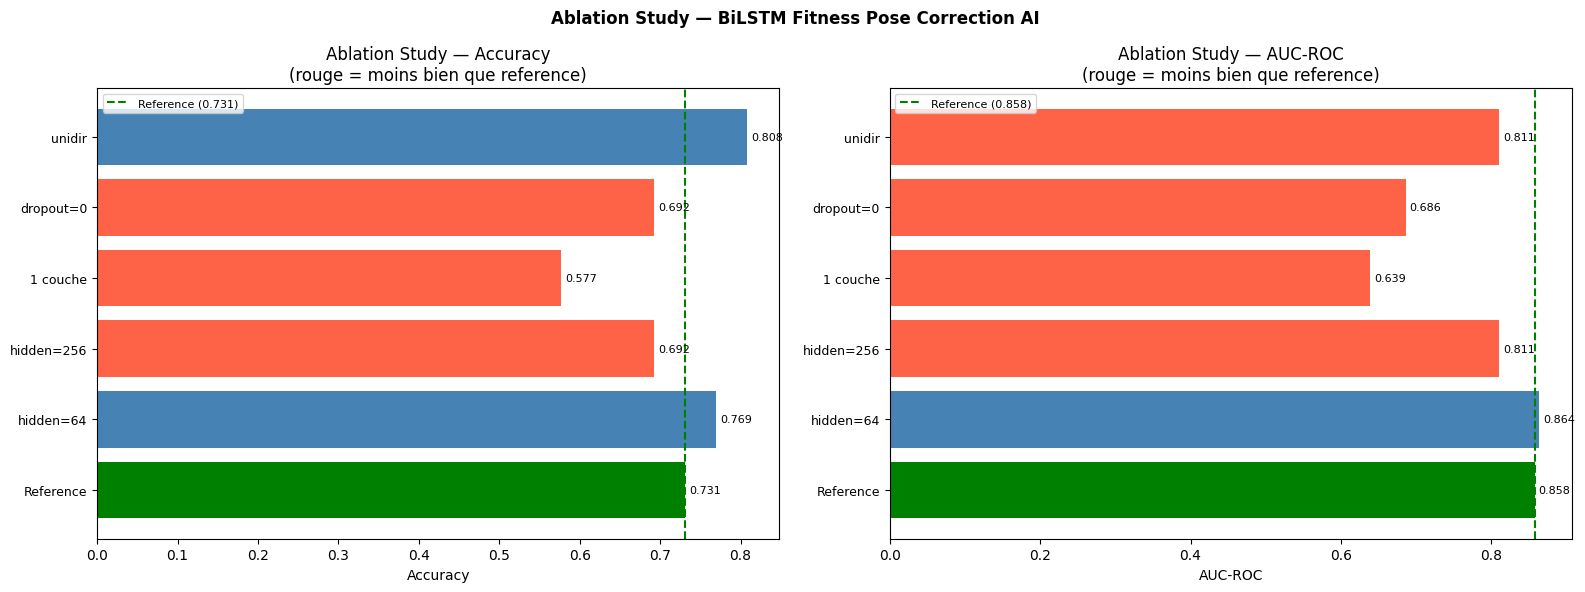

ablation_study.png sauvegarde


In [70]:
#  Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names      = list(ablation_results.keys())
names_short = [
    'Reference',
    'hidden=64',
    'hidden=256',
    '1 couche',
    'dropout=0',
    'unidir',
]
accs = [ablation_results[n]['accuracy'] for n in names]
aucs = [ablation_results[n]['auc']      for n in names]

# Couleurs : reference en vert, mieux en bleu, moins bien en rouge
ref_acc_val = accs[0]
ref_auc_val = aucs[0]

colors_acc = []
for i, a in enumerate(accs):
    if i == 0:
        colors_acc.append('green')
    elif a >= ref_acc_val:
        colors_acc.append('steelblue')
    else:
        colors_acc.append('tomato')

colors_auc = []
for i, a in enumerate(aucs):
    if i == 0:
        colors_auc.append('green')
    elif a >= ref_auc_val:
        colors_auc.append('steelblue')
    else:
        colors_auc.append('tomato')

x = np.arange(len(names_short))

# Accuracy
axes[0].barh(x, accs, color=colors_acc)
axes[0].set_yticks(x)
axes[0].set_yticklabels(names_short, fontsize=9)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Ablation Study — Accuracy\n(rouge = moins bien que reference)')
axes[0].axvline(x=ref_acc_val, color='green', linestyle='--',
                linewidth=1.5, label=f'Reference ({ref_acc_val:.3f})')
axes[0].legend(fontsize=8)
for i, v in enumerate(accs):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

# AUC
axes[1].barh(x, aucs, color=colors_auc)
axes[1].set_yticks(x)
axes[1].set_yticklabels(names_short, fontsize=9)
axes[1].set_xlabel('AUC-ROC')
axes[1].set_title('Ablation Study — AUC-ROC\n(rouge = moins bien que reference)')
axes[1].axvline(x=ref_auc_val, color='green', linestyle='--',
                linewidth=1.5, label=f'Reference ({ref_auc_val:.3f})')
axes[1].legend(fontsize=8)
for i, v in enumerate(aucs):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Ablation Study — BiLSTM Fitness Pose Correction AI',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE}/results/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('ablation_study.png sauvegarde')




In [71]:
#  Resume Jour 6
print('=' * 50)
print('JOUR 6 TERMINE')
print('=' * 50)
print()
print('done:')
print('  1. Teste 6 configurations du BiLSTM')
print('  2. Modifie un seul parametre a la fois')
print('  3. Compare avec la reference (configuration originale)')
print('  4. Justifie experimentalement chaque choix architectural')
print()
print('Fichier cree :')
print(f'  ablation_study.png  -> {BASE}/results/')
print()


JOUR 6 TERMINE

done:
  1. Teste 6 configurations du BiLSTM
  2. Modifie un seul parametre a la fois
  3. Compare avec la reference (configuration originale)
  4. Justifie experimentalement chaque choix architectural

Fichier cree :
  ablation_study.png  -> /content/fitness_data/results/



In [72]:
from google.colab import files
files.download('/content/fitness_data/processed/model.pt')
files.download('/content/fitness_data/processed/scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>